In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, chi2, t, norm

In [2]:
print('-' * 50)
print('Задание 1')

--------------------------------------------------
Задание 1


In [54]:
n = 475
a = 0.9
sigma_squared = 12.96
gamma = 0.95
alpha = 0.05

sigma = np.sqrt(sigma_squared)

In [55]:
print('Пункт 1.1:')
data = np.random.normal(a, sigma, n)

bins = int(np.round(np.log2(n) + 1)) # Формула Стерджеса

Пункт 1.1:


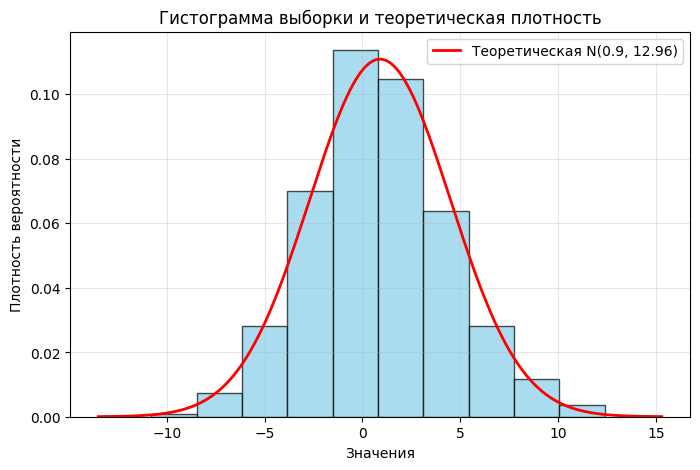

In [56]:
plt.figure(figsize=(8, 5))

# Строим гистограмму
plt.hist(data, bins=bins, density=True, edgecolor='black', alpha=0.7, color='skyblue')

# Оформление
plt.title('Гистограмма выборки и теоретическая плотность')
plt.xlabel('Значения')
plt.ylabel('Плотность вероятности')

# Теоретическая плотность
x_vals = np.linspace(a - 4*sigma, a + 4*sigma, 1000)
theoretical = norm.pdf(x_vals, loc=a, scale=sigma)
plt.plot(x_vals, theoretical, 'r-', linewidth=2, label=f'Теоретическая N({a}, {sigma_squared})')

# Добавляем легенду
plt.legend()

plt.grid(True, linestyle='-', alpha=0.3)

# Показываем результат
plt.show()

In [58]:
print('Пункт 1.2:')

sample_mean = np.mean(data)
sample_variance_biased = np.var(data, ddof=0)

print('Выборочное среднее:', sample_mean)
print('Выборочная дисперсия:', sample_variance_biased)

print(f"\nОтклонение среднего: {sample_mean - 0.9:.6f}")
print(f"Отклонение дисперсии: {sample_variance_biased - 12.96:.6f}")
print(f"Относительное отклонение дисперсии: {(sample_variance_biased - 12.96)/12.96*100:.2f}%")

Пункт 1.2:
Выборочное среднее: 0.9146539097894179
Выборочная дисперсия: 12.605115848774144

Отклонение среднего: 0.014654
Отклонение дисперсии: -0.354884
Относительное отклонение дисперсии: -2.74%


In [59]:
print('Пункт 1.3:')

# Оценки максимального правдоподобия
ML_mean = np.mean(data)                        # = sample_mean
ML_variance = np.var(data, ddof=0)             # = sample_variance_biased

# Несмещенная оценка дисперсии
unbiased_variance = np.var(data, ddof=1)

print(f'Оценка матожидания (МП): {ML_mean:.6f}')
print(f'Оценка дисперсии (МП, смещенная): {ML_variance:.6f}')
print(f'Несмещенная оценка дисперсии: {unbiased_variance:.6f}')

Пункт 1.3:
Оценка матожидания (МП): 0.914654
Оценка дисперсии (МП, смещенная): 12.605116
Несмещенная оценка дисперсии: 12.631709


In [61]:
print('\nПункт 1.4:')

# Параметры
gamma = 0.95
n = 475
alpha = 1 - gamma

# Несмещенное стандартное отклонение (для интервала матожидания)
std_unbiased = np.sqrt(unbiased_variance)

# ----- 1. Доверительный интервал для математического ожидания -----
t_crit = t.ppf((1 + gamma) / 2, df=n-1)  # квантиль Стьюдента
margin = t_crit * std_unbiased / np.sqrt(n)
ci_mean = (ML_mean - margin, ML_mean + margin)

print(f'Доверительный интервал для матожидания (γ={gamma}):')
print(f'  [{ci_mean[0]:.6f}; {ci_mean[1]:.6f}]')

# ----- 2. Доверительный интервал для дисперсии -----
chi2_low = chi2.ppf((1 - gamma) / 2, df=n-1)   # левый квантиль
chi2_high = chi2.ppf((1 + gamma) / 2, df=n-1)  # правый квантиль

ci_var_low = (n-1) * unbiased_variance / chi2_high
ci_var_high = (n-1) * unbiased_variance / chi2_low

print(f'\nДоверительный интервал для дисперсии (γ={gamma}):')
print(f'  [{ci_var_low:.6f}; {ci_var_high:.6f}]')


Пункт 1.4:
Доверительный интервал для матожидания (γ=0.95):
  [0.594217; 1.235091]

Доверительный интервал для дисперсии (γ=0.95):
  [11.166038; 14.407770]


In [63]:
print('\nПункт 1.5:')
print(f'Гипотеза H0: данные распределены по закону N({a}, {sigma_squared})')
print(f'Уровень значимости α = {alpha}')

# 1. Количество интервалов
k = int(np.round(1 + np.log2(n)))
print(f'\n1. Количество интервалов (Стерджес): k = {k}')

# 2. Наблюдаемые частоты
observed_freq, bin_edges = np.histogram(data, bins=k)
print(f'\n2. Наблюдаемые частоты: {observed_freq}')

# 3. Теоретические частоты
theor_probs = []
for i in range(len(bin_edges) - 1):
    prob = norm.cdf(bin_edges[i+1], a, sigma) - norm.cdf(bin_edges[i], a, sigma)
    theor_probs.append(prob)
theor_freq = np.array(theor_probs) * n
print(f'\n3. Теоретические частоты: {theor_freq}')

# 4. Объединение малых интервалов
min_freq = 5
merged_obs = []
merged_theor = []
temp_obs = 0
temp_theor = 0

for i in range(len(observed_freq)):
    temp_obs += observed_freq[i]
    temp_theor += theor_freq[i]
    
    if temp_theor >= min_freq or i == len(observed_freq) - 1:
        if temp_theor > 0:
            merged_obs.append(temp_obs)
            merged_theor.append(temp_theor)
        temp_obs = 0
        temp_theor = 0

print(f'\n4. После объединения (np_i ≥ {min_freq}):')
print(f'   Наблюдаемые частоты: {merged_obs}')
print(f'   Теоретические частоты: {merged_theor}')

# 5. Статистика χ²
chi2_stat = sum((merged_obs[i] - merged_theor[i])**2 / merged_theor[i] 
                for i in range(len(merged_obs)))
print(f'\n5. Статистика χ² = {chi2_stat:.6f}')

# 6. Критическое значение
df = len(merged_obs) - 1
chi2_crit = chi2.ppf(1 - alpha, df)
print(f'\n6. Степени свободы: ν = {df}')
print(f'   Критическое значение χ²_{alpha}({df}) = {chi2_crit:.6f}')

# 7. Вывод
print(f'\n7. Результат проверки:')
if chi2_stat > chi2_crit:
    print(f'   χ² = {chi2_stat:.4f} > {chi2_crit:.4f} → H0 ОТВЕРГАЕТСЯ')
    print('   Распределение выборки НЕ соответствует нормальному')
else:
    print(f'   χ² = {chi2_stat:.4f} ≤ {chi2_crit:.4f} → H0 НЕ ОТВЕРГАЕТСЯ')
    print('   Распределение выборки соответствует нормальному')


Пункт 1.5:
Гипотеза H0: данные распределены по закону N(0.9, 12.96)
Уровень значимости α = 0.050000000000000044

1. Количество интервалов (Стерджес): k = 10

2. Наблюдаемые частоты: [  1   8  31  77 125 115  70  31  13   4]

3. Теоретические частоты: [  1.92824864   9.73099453  32.88147343  74.44198974 112.96731182
 114.9369352   78.4048258   35.85146092  10.98408233   2.2534439 ]

4. После объединения (np_i ≥ 5):
   Наблюдаемые частоты: [np.int64(9), np.int64(31), np.int64(77), np.int64(125), np.int64(115), np.int64(70), np.int64(31), np.int64(13), np.int64(4)]
   Теоретические частоты: [np.float64(11.65924316874769), np.float64(32.88147342982964), np.float64(74.44198974492066), np.float64(112.96731182125588), np.float64(114.93693520276288), np.float64(78.4048258049666), np.float64(35.85146092168344), np.float64(10.984082325613148), np.float64(2.2534439047428996)]

5. Статистика χ² = 5.364926

6. Степени свободы: ν = 8
   Критическое значение χ²_0.050000000000000044(8) = 15.507313

7

In [6]:
print('-' * 50)
print('Задание 2')

--------------------------------------------------
Задание 2


In [43]:
a_true = 1.5
alpha_criterion = 0.001
gamma = 0.99
n = 400

math_exp = 1 / a_true

In [33]:
data = np.random.exponential(scale = math_exp, size = n)

bins = int(np.round(np.log2(n) + 1)) # Формула Стерджеса

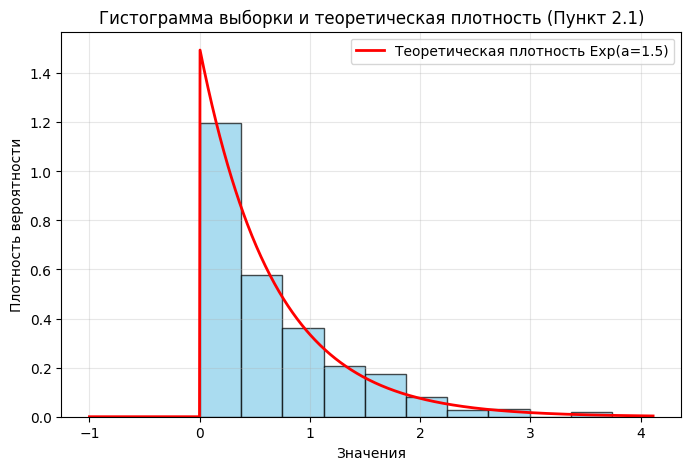

In [39]:
plt.figure(figsize=(8, 5))

# Строим гистограмму
plt.hist(data, bins=bins, density=True, edgecolor='black', alpha=0.7, color='skyblue')

# Оформление
plt.title('Гистограмма выборки и теоретическая плотность (Пункт 2.1)')
plt.xlabel('Значения')
plt.ylabel('Плотность вероятности')

# Теоретическая плотность
x_vals = np.linspace(-1, np.max(data) * 1.1, 1000)
theoretical = expon.pdf(x_vals, loc=0, scale=math_exp)
plt.plot(x_vals, theoretical, 'r-', linewidth=2, label=f'Теоретическая плотность Exp(a={a_true})')

# Добавляем легенду
plt.legend()

plt.grid(True, linestyle='-', alpha=0.3)

# Показываем результат
plt.show()

In [41]:
print('Пункт 2.2:')

sample_mean = np.mean(data)
a_mm = 1 / sample_mean

print('Параметр a, данный в условии задачи:', a_true)
print('Точечная оценка параметра  a, найденная методом моментов:', a_mm)

Пункт 2.2:
Параметр a, данный в условии задачи: 1.5
Точечная оценка параметра  a, найденная методом моментов: 1.5049944865894302


In [42]:
print('Пункт 2.3:')

exp_val = sample_mean
var = np.var(data, ddof=1)

print('Точечная оценка математического ожидания:', exp_val)
print('Точечная оценка дисперсии:', var)

Пункт 2.3:
Точечная оценка математического ожидания: 0.6644542614014272
Точечная оценка дисперсии: 0.44541463447554


In [48]:
print('Пункт 2.4:')

alpha_conf = 1 - gamma
sample_sum = np.sum(data)

chi2_low = chi2.ppf(alpha_conf / 2, df=(n*2))
chi2_high = chi2.ppf(1 - alpha_conf / 2, df=(n*2))

mu_lower = 2 * sample_sum / chi2_high
mu_upper = 2 * sample_sum / chi2_low

var_lower = mu_lower ** 2
var_upper = mu_upper ** 2

print(f"Доверительный интервал для матожидания (γ={gamma}):")
print(f"[{mu_lower:.4f}, {mu_upper:.4f}]")
print(f"Точечная оценка: {sample_mean:.4f}")
print(f"Теоретическое значение: {1/a_true:.4f}")

print(f"\nДоверительный интервал для дисперсии (γ={gamma}):")
print(f"[{var_lower:.4f}, {var_upper:.4f}]")
print(f"Точечная оценка: {var:.4f}")
print(f"Теоретическое значение: {1/a_true**2:.4f}")


Пункт 2.4:
Доверительный интервал для матожидания (γ=0.99):
[0.5862, 0.7586]
Точечная оценка: 0.6645
Теоретическое значение: 0.6667

Доверительный интервал для дисперсии (γ=0.99):
[0.3436, 0.5755]
Точечная оценка: 0.4454
Теоретическое значение: 0.4444


In [50]:
print('Пункт 2.5:')

k = 15

a_est = a_mm  # оценка параметра

# Теоретические вероятности (одинаковые для равновероятных интервалов)
p_i = 1 / k

# Границы интервалов (k-1 граница)
boundaries = [0] + [-np.log(1 - j/k) / a_est for j in range(1, k)] + [np.inf]

observed, _ = np.histogram(data, bins=boundaries)
expected = np.full(k, n * p_i)  # массив из k одинаковых значений

chi2_stat = np.sum((observed - expected)**2 / expected)

df = k - 1 - 1
alpha_criterion = 0.001  # из условия
chi2_crit = chi2.ppf(1 - alpha_criterion, df)

print(f"Количество интервалов: {k}")
print(f"Длина observed: {len(observed)}")
print(f"Наблюдаемые частоты: {observed}")
print(f"Ожидаемые частоты: {expected}")

if chi2_stat > chi2_crit:
    print("Гипотеза отвергается: распределение не показательное")
else:
    print("Нет оснований отвергать гипотезу о показательном распределении")

Пункт 2.5:
Количество интервалов: 15
Длина observed: 15
Наблюдаемые частоты: [38 27 23 30 27 27 24 23 14 28 24 29 21 38 27]
Ожидаемые частоты: [26.66666667 26.66666667 26.66666667 26.66666667 26.66666667 26.66666667
 26.66666667 26.66666667 26.66666667 26.66666667 26.66666667 26.66666667
 26.66666667 26.66666667 26.66666667]
Нет оснований отвергать гипотезу о показательном распределении


In [64]:
print('Задание 3:')

n = 475
alpha = 0.05
r_xy = -0.43

a_x = 0.9
sigma_squared_x = 12.96

a_y = 3.2
sigma_squared_y = 4.5


Задание 3:
